# Game-Level Clustering

Aggregate reviews to game level and cluster games into market segments based on behavioral profiles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_parquet('../data/steam_reviews_sampled.parquet')
df['playtime_hours'] = df['author.playtime_at_review'] / 60


## Game-Level Aggregation
* Aggregated ~2.5M reviews into 315 games
* Features per game: `n_reviews`, `rec_rate`, `median_playtime`, `pur_free`, `pur_early_access`, `pur_steam_purchase`, `reviewer_median_games_owned`, `reviewer_median_n_reviews`

In [2]:
game_agg = df.groupby('app_id').agg(
    app_name=('app_name', 'first'),
    n_reviews = ('recommended','size'),
    rec_rate = ('recommended','mean'),
    median_playtime = ('playtime_hours','median'),
    pur_free = ('received_for_free','mean'),
    pur_early_access = ('written_during_early_access','mean'),
    pur_steam_purchase = ('steam_purchase','mean'),
    reviewer_median_games_owned = ('author.num_games_owned','median'),
    reviewer_median_n_reviews = ('author.num_reviews','median'),
).reset_index()


In [3]:
print(game_agg.shape)
game_agg.head(10)

(315, 10)


,app_id,app_name,n_reviews,rec_rate,median_playtime,pur_free,pur_early_access,pur_steam_purchase,reviewer_median_games_owned,reviewer_median_n_reviews
0,70,Half-Life,6879,0.96,8.75,0.05,0.00,0.77,78.00,8.00
1,240,Counter-Strike: Source,14170,0.96,27.10,0.04,0.00,0.63,48.00,4.00
2,420,Half-Life 2: Episode Two,2820,0.96,5.93,0.04,0.00,0.74,108.00,13.00
3,620,Portal 2,27879,0.99,11.88,0.02,0.00,0.79,69.00,6.00
4,2870,X Rebirth,840,0.45,18.55,0.00,0.00,0.68,197.50,7.00
5,4000,Garry's Mod,78663,0.97,68.60,0.04,0.00,0.84,41.00,4.00
6,7510,X-Blades,337,0.61,2.44,0.07,0.00,0.38,236.00,15.00
7,8870,BioShock Infinite,12873,0.95,13.10,0.01,0.00,0.73,130.00,7.00
8,8930,Sid Meier's Civilization V,20568,0.96,86.43,0.01,0.00,0.61,100.00,4.00
9,32470,STAR WARS™ Empire at War: Gold Pack,2466,0.97,33.23,0.02,0.00,0.85,58.00,4.00


In [4]:
game_agg.describe()

,app_id,n_reviews,rec_rate,median_playtime,pur_free,pur_early_access,pur_steam_purchase,reviewer_median_games_owned,reviewer_median_n_reviews
count,315.00,315.00,315.00,315.00,315.00,315.00,315.00,315.00,315.00
mean,"506,883.69","8,284.69",0.84,24.91,0.03,0.12,0.77,108.85,6.57
std,"270,721.49","18,124.29",0.17,29.22,0.03,0.27,0.16,60.40,5.98
min,70.00,24.00,0.18,0.58,0.00,0.00,0.00,17.00,1.00
25%,"291,945.00",792.50,0.80,8.93,0.01,0.00,0.70,69.25,4.00
50%,"501,080.00","2,692.00",0.90,15.70,0.02,0.00,0.80,99.00,6.00
75%,"646,740.00","7,466.50",0.96,29.76,0.03,0.00,0.88,137.25,8.00
max,"1,291,340.00","197,311.00",1.00,240.85,0.27,1.00,0.98,418.50,97.00


## Standardization
* Features have wildly different scales (n_reviews = 70-1.29M, rec_rate = 0.18-1.0)
* StandardScaler applied. Transforms each feature to mean 0, std 1
* Without this, large-number features like n_reviews would dominate clustering

In [5]:
from sklearn.preprocessing import StandardScaler
features = ['n_reviews', 'rec_rate','median_playtime','pur_free','pur_early_access',
            'pur_steam_purchase','reviewer_median_games_owned','reviewer_median_n_reviews']

scaler = StandardScaler()
scaled = scaler.fit_transform(game_agg[features])

## Choosing K - Elbow Method
Run K-Means for K=2 to K=10 and plot inertia to find the optimal number of clusters.

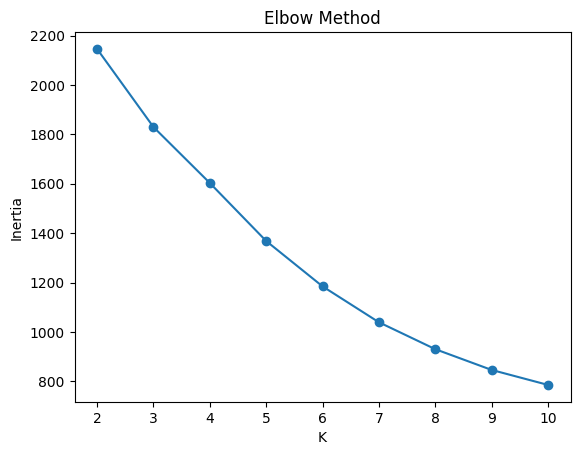

In [6]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.plot(K_range,inertias,marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Silhouette Score
No clear elbow. Use silhouette score as a second measure. Ranges from -1 to 1, higher is better.

In [7]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(scaled)
    score = silhouette_score(scaled,labels)
    print(f'K={k}: silhouette = {score:.4f}')

K=2: silhouette = 0.4080
K=3: silhouette = 0.3752
K=4: silhouette = 0.3162
K=5: silhouette = 0.3313
K=6: silhouette = 0.2640
K=7: silhouette = 0.2146
K=8: silhouette = 0.2318
K=9: silhouette = 0.2279
K=10: silhouette = 0.2300


## Fitting K=4
K=2 scored highest (0.408) but too simple. K=4 (0.316) chosen. Good balance between score and interpretability.

In [8]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
game_agg['cluster'] = km.fit_predict(scaled)

game_agg.groupby('cluster')[features].mean()

,n_reviews,rec_rate,median_playtime,pur_free,pur_early_access,pur_steam_purchase,reviewer_median_games_owned,reviewer_median_n_reviews
cluster,,,,,,,,
0,"3,073.20",0.61,8.66,0.07,0.11,0.46,161.17,11.66
1,"4,858.90",0.88,19.25,0.02,0.02,0.81,108.11,6.33
2,"44,291.70",0.89,91.42,0.03,0.04,0.75,66.97,3.70
3,"3,710.00",0.82,18.97,0.03,0.74,0.85,97.29,5.46


In [9]:
game_agg['cluster'].value_counts()

cluster
1    214
3     36
0     35
2     30
Name: count, dtype: int64

## Cluster Interpretations
* Cluster 0 - Polarizing AAA (35 games): lowest rec_rate (0.61), disappointing sequels and controversial releases (COD Infinite Warfare, Metal Gear Survive, WWE 2K20)
* Cluster 1 - Mainstream (214 games): the bulk of Steam, well-received, moderate playtime (Portal 2, Hollow Knight, Sekiro)
* Cluster 2 - Blockbusters (30 games): highest reviews and playtime (91h) (GTA V, Stardew Valley, PUBG, Rimworld)
* Cluster 3 - Early Access (36 games): 74% of reviews during early access, 82% rec_rate matches bias analysis finding (Factorio, Satisfactory, Phasmophobia)

## Limitations
* Dataset skews toward popular games - truly niche indie titles aren't represented, so a niche cluster can't emerge

In [10]:
for c in range(4):
    print(f'\n=== Cluster {c} ===')
    print(game_agg[game_agg['cluster'] == c]['app_name'].tolist())


=== Cluster 0 ===
['X Rebirth', 'X-Blades', 'Tomb Raider', 'Takedown: Red Sabre', 'Volgarr the Viking', 'Deus Ex: The Fall', 'Torment: Tides of Numenera', 'Guacamelee! Super Turbo Championship Edition', 'RollerCoaster Tycoon World', 'Warhammer 40,000: Dawn of War III', 'Call of Duty: Infinite Warfare', 'For Honor', 'Down To One', 'Urban Empire', 'Shadow Complex Remastered', 'Umbrella Corps', 'Neon Hardcorps', 'The Elder Scrolls V: Skyrim Special Edition', 'Just Cause 4', 'Dead Rising 4', 'METAL GEAR SURVIVE', 'Ancestors Legacy', 'Rapture Rejects', 'Doki Doki Literature Club', 'Hunt Down The Freeman', 'DYNASTY WARRIORS 9', 'Slipstream', 'Identity', 'Totally Accurate Battlegrounds', 'HITMAN™ 2', 'WWE 2K20', 'Cube World', "Grimm's Hollow", 'Stay Out', 'Helltaker']

=== Cluster 1 ===
['Half-Life', 'Counter-Strike: Source', 'Half-Life 2: Episode Two', 'Portal 2', 'BioShock Infinite', 'STAR WARS™ Empire at War: Gold Pack', 'Batman: Arkham Asylum GOTY Edition', 'Super Meat Boy', 'The Sims(TM

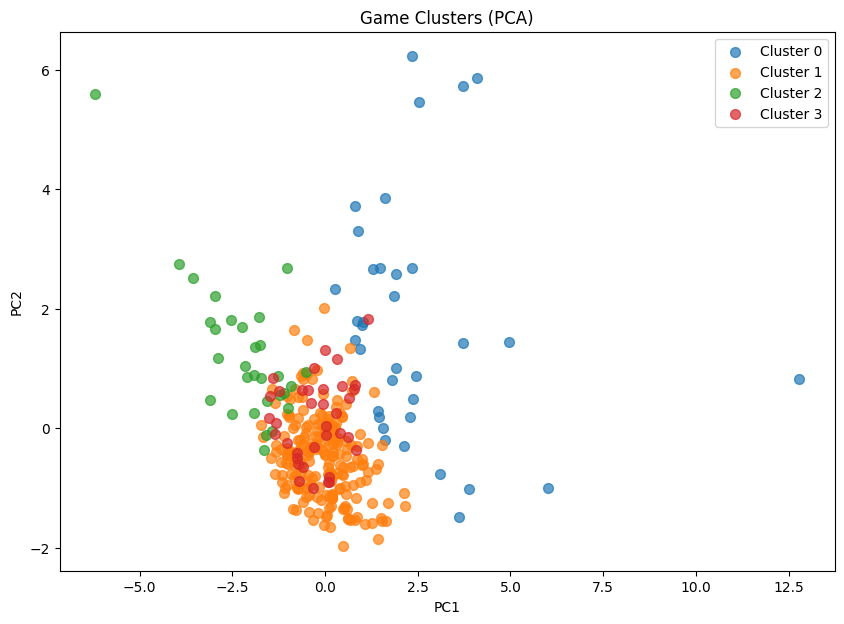

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled)

plt.figure(figsize=(10, 7))
for c in range(4):
    mask = game_agg['cluster'] == c
    plt.scatter(reduced[mask, 0], reduced[mask, 1], label=f'Cluster {c}', alpha=0.7,s=50)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Game Clusters (PCA)')
plt.legend()
plt.show()